# **Aula 2 - Arquitetura e Camada Oculta**

No Bloco 1, vimos como um **único neurônio** funciona: ele recebe algumas entradas, combina cada uma com um peso, soma um viés, e (no caso do perceptron) aplica um limiar para decidir entre duas classes. Isso já é suficiente para resolver problemas simples -- desde que as classes sejam **linearmente separáveis**, ou seja, que exista uma única fronteira (uma reta, no caso de 2 entradas) capaz de separar corretamente os exemplos positivos dos negativos.

Mas a maioria dos problemas reais não é assim: as classes se misturam, as relações entre as variáveis são não lineares, e nenhuma fronteira única resolve o problema. Um único neurônio, sozinho, não tem capacidade suficiente para isso -- por mais que ajustemos seus pesos, ele continua traçando apenas uma fronteira reta.

A solução não é trocar o neurônio por algo mais complexo, e sim **combinar vários neurônios simples** -- os mesmos blocos do Bloco 1 (entrada ponderada + viés + ativação) -- organizados em **camadas**. Cada neurônio de uma camada aprende a olhar para o problema de um ângulo diferente, e a camada seguinte combina essas leituras parciais. É essa composição de fronteiras simples que permite representar fronteiras de decisão muito mais complexas -- e é isso que chamamos de **rede neural**.

Nesta aula, vamos usar exatamente o mesmo exemplo do e-mail suspeito de spam do Bloco 1, agora processado por uma pequena rede com uma camada oculta, para ver concretamente o que muda (e o que se mantém) quando saímos de um neurônio isolado para uma rede.

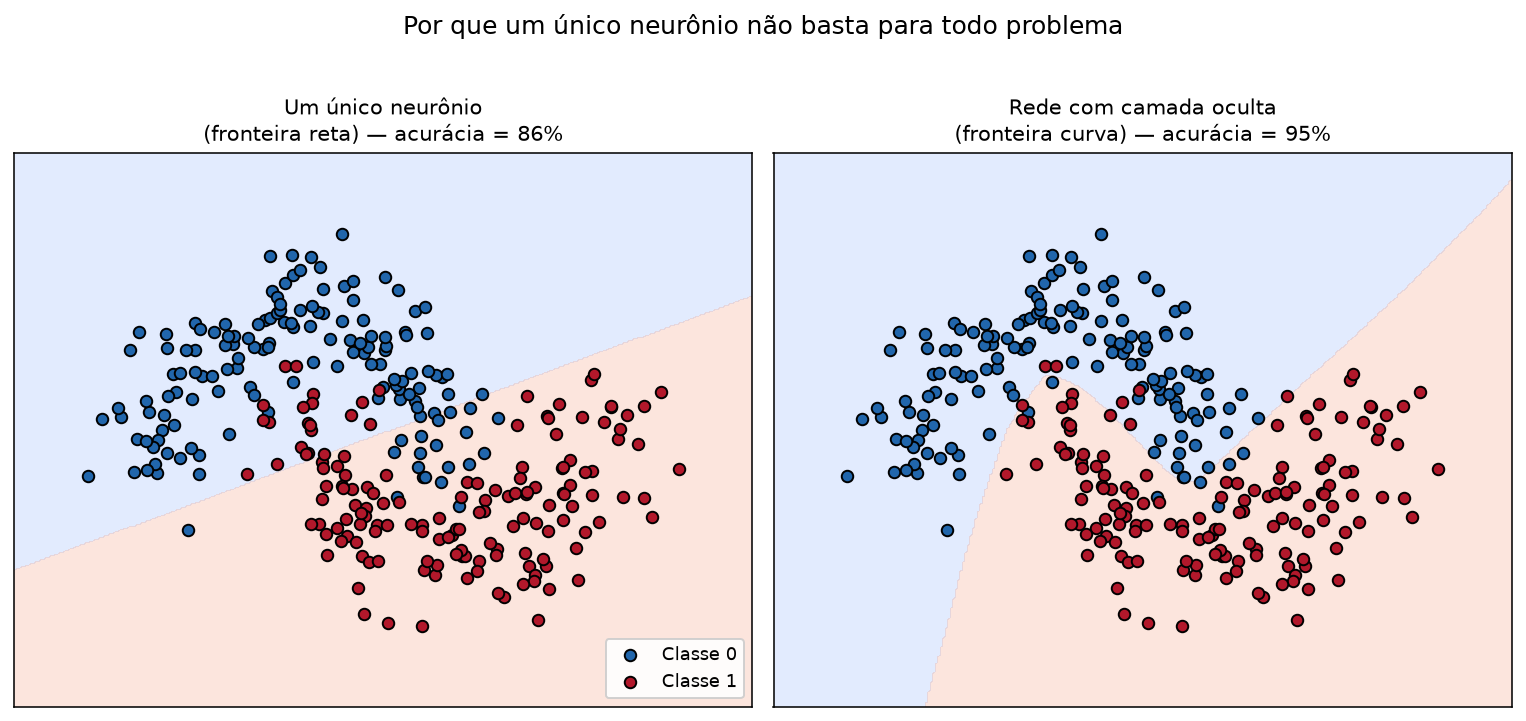

Neste exemplo (200 pontos em duas classes com formato de "luas" entrelaçadas, um caso classicamente não linearmente separável), um único neurônio (regressão logística) erra sistematicamente os pontos onde as duas classes se encurvam uma para dentro da outra, atingindo 86% de acurácia -- o melhor que uma única reta consegue fazer. Uma rede pequena, com uma camada oculta de 32 neurônios, aprende uma fronteira curva que acompanha o formato real dos dados e chega a 95% de acurácia, usando exatamente os mesmos ingredientes do Bloco 1 (soma ponderada + viés + ativação), só que combinados em maior número.

**1. Arquitetura da Rede Neural**

Agora vamos ampliar a ideia do neurônio isolado para uma **rede neural pequena**, mas mantendo exatamente o mesmo problema: avaliar se um e-mail apresenta sinais de spam.

A diferença é que, em vez de uma única função produzir a pontuação final diretamente, teremos **várias funções trabalhando em sequência**. Ex.: Camada de Entrada → Função/Camada Oculta (3 funções) → Função/Camada de Saída.

Vamos usar a seguinte estrutura:

- **Camada de entrada**: recebe os 3 valores do e-mail (`links`, `linguagem suspeita`, `confiabilidade do remetente`).
- **Camada oculta**: 3 neurônios intermediários, cada um combinando essas entradas de um jeito diferente.
- **Camada de saída**: 1 neurônio final, responsável por transformar o processamento anterior em uma pontuação final.

Isso não é aleatório: cada neurônio da camada oculta tem seu próprio conjunto de pesos (veja a matriz `weights_hidden` logo abaixo) e, por isso, "enxerga" o e-mail por um ângulo diferente. Olhando para os pesos que usaremos neste exemplo:

- **Neurônio oculto 1** pondera links e linguagem suspeita de forma parecida (0.3 e 0.4) e reage fortemente a remetentes pouco confiáveis (peso -0.4).
- **Neurônio oculto 2** é o mais sensível à confiabilidade do remetente (peso -0.5), dando menos peso a links e linguagem suspeita.
- **Neurônio oculto 3** é o que mais reage à linguagem suspeita (peso 0.5), e quase ignora a confiabilidade do remetente (peso -0.2, o mais fraco dos três).

Ou seja: em vez de fazer uma única pergunta — "esse e-mail parece spam?" —, a rede faz três leituras parciais e complementares do mesmo e-mail, e só depois combina essas leituras na camada de saída para chegar ao resultado final.

Neste exemplo, usaremos:

- **Camada de entrada** com 3 valores.
- **Camada oculta** com 3 neurônios e ativação ReLU.
- **Camada de saída** com 1 neurônio e ativação sigmoid, para gerar uma saída entre 0 e 1.

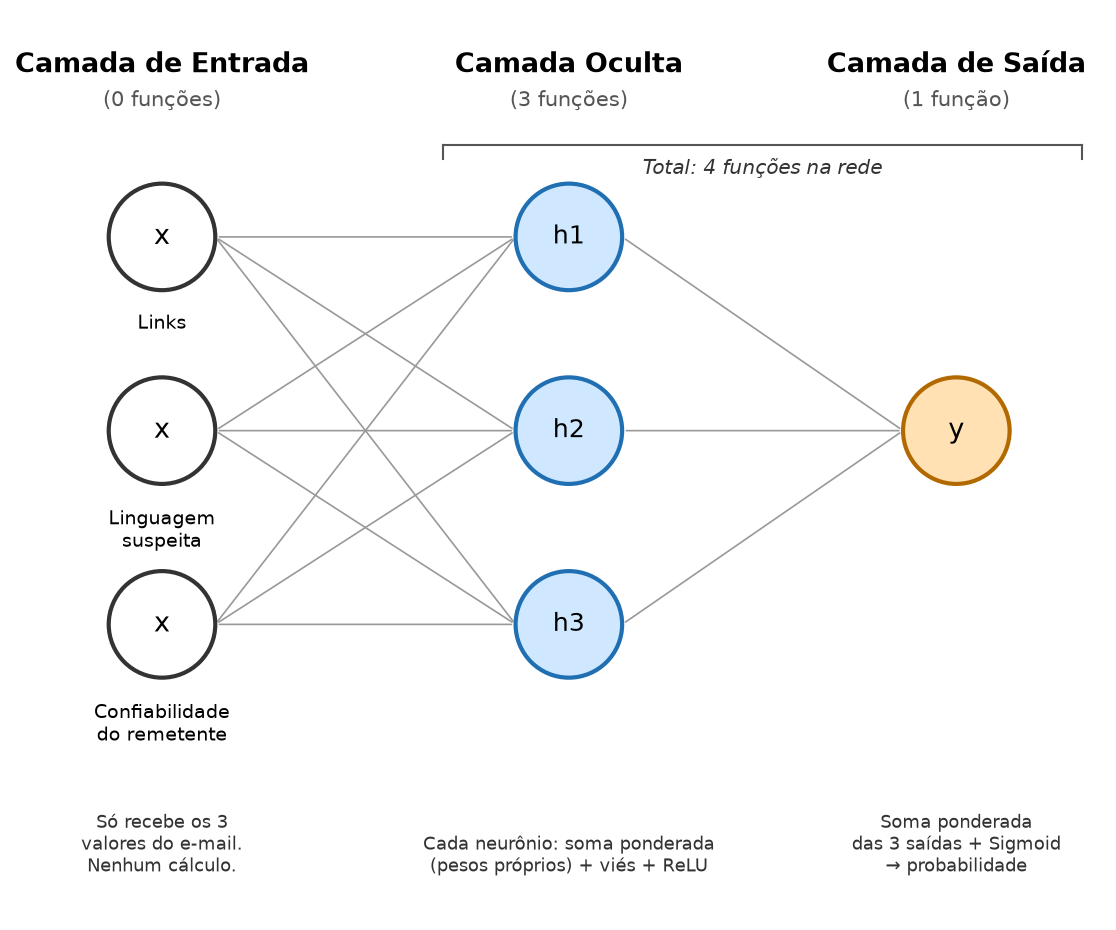

**O que são ReLU e sigmoid, e por que usamos funções diferentes em cada camada?**

Lembre do limiar do perceptron (Bloco 1): `score >= 0 -> 1`, caso contrário `0` -- uma função de ativação simples, que transforma qualquer pontuação em uma decisão binária abrupta (é spam, ou não é). ReLU e sigmoid são as duas funções de ativação mais usadas em redes neurais modernas, e cada uma resolve um problema diferente:

- **ReLU** (*Rectified Linear Unit*): `ReLU(x) = max(0, x)`. Se a entrada é negativa, a saída é zero; se é positiva, a saída é a própria entrada, sem alteração. Diferente do limiar do perceptron, a ReLU não "decide" nada -- ela só descarta ativações negativas e preserva a intensidade das positivas. Usamos ReLU na **camada oculta** porque isso permite que cada neurônio "aprenda" o quanto ele foi ativado (não apenas se foi ou não), o que dá à rede muito mais capacidade de representar relações complexas do que um limiar binário permitiria.

- **Sigmoid**: `sigmoid(x) = 1 / (1 + e^(-x))`. Comprime qualquer número real para o intervalo entre 0 e 1, de forma suave -- sem o salto abrupto do limiar do perceptron. Usamos sigmoid na **camada de saída** porque o resultado final -- uma probabilidade de spam -- precisa estar entre 0 e 1 para ser interpretável dessa forma: `sigmoid(0) = 0.5`, valores bem positivos se aproximam de 1, e valores bem negativos se aproximam de 0.

Em resumo: a ReLU processa informação dentro da rede, preservando o sinal de cada neurônio o mais "rico" possível; a sigmoid entra só no fim, para transformar esse processamento em algo interpretável como uma probabilidade -- assim como o limiar do perceptron transformava a pontuação em uma decisão, só que agora de um jeito suave e contínuo, em vez de abrupto.

**Uma leitura histórica:** o limiar do perceptron (ROSENBLATT, 1958) foi a primeira função de ativação usada em redes neurais artificiais, e resolvia bem o problema da época -- uma decisão binária simples. Décadas depois, ao empilhar neurônios em várias camadas, a comunidade de aprendizado de máquina passou a preferir funções suaves e contínuas como a sigmoid e, mais recentemente, a ReLU: elas preservam mais informação entre as camadas do que um limiar abrupto, o que se mostrou essencial para treinar redes maiores de forma eficiente.

In [28]:
import numpy as np

# Vamos reutilizar o mesmo e-mail de exemplo
inputs = np.array([8.0, 7.0, 2.0])  # [links, linguagem_suspeita, confiabilidade_remetente]

# Pesos da camada oculta (3 entradas x 3 neuronios ocultos)
# Cada coluna mostra como um neuronio oculto combina os tres sinais do e-mail.
weights_hidden = np.array([
    [0.3, 0.2, 0.1],   # influencia de links
    [0.4, 0.3, 0.5],   # influencia de linguagem suspeita
    [-0.4, -0.5, -0.2] # influencia da confiabilidade do remetente
])

# Pesos do neuronio de saida
weights_output = np.array([0.2, 0.05, 0.15])

print('Vetor de entrada do e-mail:', inputs)
print('Pesos da camada oculta:')
print(weights_hidden)
print('Pesos da camada de saida:', weights_output)

Vetor de entrada do e-mail: [8. 7. 2.]
Pesos da camada oculta:
[[ 0.3  0.2  0.1]
 [ 0.4  0.3  0.5]
 [-0.4 -0.5 -0.2]]
Pesos da camada de saida: [0.2  0.05 0.15]


**Se temos uma camada de entrada, com 3 valores, e tres neurônios que recebem exatamente os mesmos valores, por que os 3 neurônios ocultos não ficam iguais?**

Repare que os 3 neurônios da camada oculta recebem exatamente as mesmas 3 entradas (`links`, `linguagem suspeita`, `confiabilidade do remetente`). Isso levanta uma pergunta natural: se eles são treinados ao mesmo tempo, por que não acabam aprendendo os mesmos pesos?

A resposta é que, se todos começassem com os **mesmos pesos iniciais**, de fato ficariam idênticos para sempre — isso é conhecido como o problema da **quebra de simetria** (symmetry breaking):

- mesma entrada + mesmos pesos → mesma saída nos 3 neurônios;
- mesma saída → mesmo erro calculado para os 3;
- mesmo erro → mesma atualização de pesos a cada passo de treino.

Ou seja, a camada oculta inteira colapsaria e se comportaria como um único neurônio, desperdiçando a capacidade extra de ter 3.

Por isso, na prática, os pesos de uma rede real **nunca são inicializados com o mesmo valor** — eles começam como valores aleatórios pequenos (ex: `np.random.randn()`, ou inicializadores como Xavier/He no Keras). Partindo de pontos diferentes, cada neurônio recebe um gradiente levemente diferente já na primeira atualização, e essa diferença se amplifica ao longo do treinamento. É isso que permite que cada neurônio aprenda a "olhar" para um aspecto diferente do problema, como vimos nos pesos hipotéticos do nosso exemplo (`weights_hidden`), onde cada neurônio pondera links/linguagem/confiabilidade de um jeito distinto.

Neste notebook os pesos são valores fixos, escolhidos manualmente para fins didáticos — não vieram de um treinamento real. Mas se fôssemos treinar essa rede de verdade, seria a inicialização aleatória que garantiria que os 3 neurônios não "colassem" um no outro.

Podemos ver isso acontecer na prática, reaproveitando a mesma base de 10 e-mails rotulados do item 1. A função `treinar_neuronio()` abaixo implementa exatamente a mesma regra de atualização de pesos do perceptron que vimos no Bloco 1 -- `pesos = pesos + learning_rate * erro * entrada` --, sem nenhuma mudança nela. A única diferença é que agora vamos chamar essa mesma função três vezes, uma para cada neurônio da camada oculta, para comparar o que acontece quando eles partem de pesos iguais versus pesos diferentes:

In [29]:
import numpy as np

# Mesma base de 10 e-mails rotulados do item 1
X = np.array([
    [9, 8, 1],
    [8, 7, 2],
    [7, 9, 1],
    [6, 8, 2],
    [8, 6, 3],
    [1, 1, 9],
    [2, 2, 8],
    [0, 1, 10],
    [3, 2, 7],
    [1, 0, 8]
], dtype=float)
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0], dtype=float)
learning_rate = 0.1

def treinar_neuronio(pesos_iniciais, bias_inicial=0.0):
    pesos = pesos_iniciais.copy()
    bias = bias_inicial
    for x_i, y_real in zip(X, y):
        score = np.dot(x_i, pesos) + bias
        y_pred = 1.0 if score >= 0 else 0.0
        erro = y_real - y_pred
        pesos = pesos + learning_rate * erro * x_i
        bias = bias + learning_rate * erro
    return pesos, bias

print("Cenario A: os 3 neuronios comecam com os MESMOS pesos iniciais (zeros)")
pesos_iguais = np.zeros(3)
for i in range(3):
    pesos_finais, bias_final = treinar_neuronio(pesos_iguais)
    print(f"  Neuronio {i+1}: pesos finais = {pesos_finais}, bias = {bias_final:.2f}")
print("  -> Os 3 neuronios ficaram IDENTICOS: a camada oculta colapsou em um so.")

print()
print("Cenario B: os 3 neuronios comecam com pesos ALEATORIOS diferentes")
np.random.seed(42)
for i in range(3):
    pesos_iniciais = np.random.randn(3) * 0.1
    pesos_finais, bias_final = treinar_neuronio(pesos_iniciais)
    print(f"  Neuronio {i+1}: pesos iniciais = {pesos_iniciais.round(3)} -> pesos finais = {pesos_finais.round(3)}, bias = {bias_final:.2f}")
print("  -> Cada neuronio aprendeu uma solucao diferente: a quebra de simetria funcionou.")

Cenario A: os 3 neuronios comecam com os MESMOS pesos iniciais (zeros)
  Neuronio 1: pesos finais = [-0.1 -0.1 -0.9], bias = -0.10
  Neuronio 2: pesos finais = [-0.1 -0.1 -0.9], bias = -0.10
  Neuronio 3: pesos finais = [-0.1 -0.1 -0.9], bias = -0.10
  -> Os 3 neuronios ficaram IDENTICOS: a camada oculta colapsou em um so.

Cenario B: os 3 neuronios comecam com pesos ALEATORIOS diferentes
  Neuronio 1: pesos iniciais = [ 0.05  -0.014  0.065] -> pesos finais = [-0.05  -0.114 -0.835], bias = -0.10
  Neuronio 2: pesos iniciais = [ 0.152 -0.023 -0.023] -> pesos finais = [-0.048 -0.223 -0.823], bias = -0.10
  Neuronio 3: pesos iniciais = [ 0.158  0.077 -0.047] -> pesos finais = [-0.042 -0.123 -0.847], bias = -0.10
  -> Cada neuronio aprendeu uma solucao diferente: a quebra de simetria funcionou.


Repare que o Cenário B não usa nenhum algoritmo novo: é o mesmo perceptron do Bloco 1, treinado três vezes de forma independente, cada vez a partir de um ponto de partida diferente. A quebra de simetria não exige uma técnica diferente de aprendizado -- só uma inicialização diferente para cada neurônio.

**2. Passo a Passo do Cálculo**

Vamos seguir o fluxo da rede em duas etapas: primeiro a camada oculta, depois a camada de saída.

a. **Primeira etapa: camada oculta**
- Cada neurônio oculto combina os 3 valores de entrada com pesos diferentes.
- Em seguida, aplicamos a ReLU para eliminar valores negativos.

In [3]:
import numpy as np

# Garante que o item 3 rode mesmo se o notebook tiver sido reiniciado a partir daqui.
# Importante: os valores abaixo sao EXATAMENTE os mesmos definidos na celula do item 1
# (mesmo e-mail, mesmos pesos) - nao e um novo exemplo, e sim a continuacao do mesmo calculo.
if 'inputs' not in globals():
    inputs = np.array([8.0, 7.0, 2.0])
    weights_hidden = np.array([
        [0.3, 0.2, 0.1],
        [0.4, 0.3, 0.5],
        [-0.4, -0.5, -0.2]
    ])
    weights_output = np.array([0.2, 0.05, 0.15])

print('1. Valores de entrada do e-mail:', inputs)
print('2. Matriz de pesos da camada oculta:', weights_hidden)
print('3. Vetor de pesos do neuronio de saida:', weights_output)

1. Valores de entrada do e-mail: [8. 7. 2.]
2. Matriz de pesos da camada oculta: [[ 0.3  0.2  0.1]
 [ 0.4  0.3  0.5]
 [-0.4 -0.5 -0.2]]
3. Vetor de pesos do neuronio de saida: [0.2  0.05 0.15]


In [31]:
## Primeira etapa de processamento
# a.1. Multiplicacao do vetor de entrada pelos pesos da camada oculta
# Parte linear da funcao
hidden_raw = np.dot(inputs, weights_hidden)
# Conferindo a conta manualmente:
# Neuronio oculto 1: 8*0.3 + 7*0.4 + 2*(-0.4) = 2.4 + 2.8 - 0.8 = 4.4
# Neuronio oculto 2: 8*0.2 + 7*0.3 + 2*(-0.5) = 1.6 + 2.1 - 1.0 = 2.7
# Neuronio oculto 3: 8*0.1 + 7*0.5 + 2*(-0.2) = 0.8 + 3.5 - 0.4 = 3.9
print('a.1. Resultado linear da camada oculta (antes da ReLU):', hidden_raw)

# a.2. Aplicar ReLU
# Parte nao linear da funcao
hidden_layer = np.maximum(0, hidden_raw)
print('a.2. Saida da camada oculta (depois da ReLU):', hidden_layer)

a.1. Resultado linear da camada oculta (antes da ReLU): [4.4 2.7 3.9]
a.2. Saida da camada oculta (depois da ReLU): [4.4 2.7 3.9]


b. **Segunda etapa: camada de saída**

- O neurônio de saída combina os resultados da camada oculta.
- Depois, a sigmoid transforma esse resultado em um valor entre 0 e 1.

In [32]:
# Recapitulando antes da segunda etapa
print('Saida da camada oculta (entrada para a camada de saida):', hidden_layer)
print('Vetor de pesos do neuronio de saida:', weights_output)

Saida da camada oculta (entrada para a camada de saida): [4.4 2.7 3.9]
Vetor de pesos do neuronio de saida: [0.2  0.05 0.15]


In [33]:
# Multiplicacao dos resultados da camada oculta pelo vetor de pesos do neuronio de saida
output_raw = np.dot(hidden_layer, weights_output)
# Calculo: 4.4*0.2 + 2.7*0.05 + 3.9*0.15 = 0.88 + 0.135 + 0.585 = 1.6
print('Resultado linear da camada de saida:', output_raw)

# Aplicar sigmoid (transformar em uma saida entre 0 e 1)
output = 1 / (1 + np.exp(-output_raw))
print(f'4. Probabilidade de spam: {output:.2f}')

Resultado linear da camada de saida: 1.6
4. Probabilidade de spam: 0.83


**3. Interpretacao do Resultado**

- Saida: aproximadamente `0.83`.
- Isso significa que, para esta rede pequena, o e-mail apresenta **alta probabilidade de ser spam**.

**Por que o valor ficou alto?**
- O e-mail tem muitos links e bastante linguagem suspeita.
- A confiabilidade do remetente e baixa, entao ela nao compensa os outros sinais.
- Os tres neuronios ocultos produziram ativacoes positivas, reforcando a suspeita na camada de saida.

**É SPAM ou Não?**
- Depende de você! Qual limiar você vai considerar? O que implica ter um limiar de 0.95 ou 0.50? Vamos debater!

**4. Diagrama Visual**

Este é o mesmo fluxo apresentado na figura da Seção 1 (entrada → camada oculta → camada de saída), agora com os valores numéricos do nosso exemplo do e-mail suspeito preenchidos em cada etapa:

```
Input Layer (3 características)              Hidden Layer (3 neurônios)        Output Layer (1 neurônio)
          ┌───────────────────────────────┐        ┌───────────────────────────────┐       ┌──────────────────────┐
          │                               │        │                               │       │                      │
Links  →  │             8.0               │───┐    │        ReLU(4.4) = 4.4        │───┐   │                      │
          │                               │   │    │                               │   │   │      Sigmoid(1.6)    │
Ling.  →  │             7.0               │───┼───▶│        ReLU(2.7) = 2.7        │───┼──▶│         ▼            │
Susp.     │                               │   │    │                               │   │   │    Prob. de Spam     │
Conf.  →  │             2.0               │───┘    │        ReLU(3.9) = 3.9        │───┘   │        ≈ 0.83        │
Remet.    │                               │        │                               │       │                      │
          └───────────────────────────────┘        └───────────────────────────────┘       └──────────────────────┘

```

**5. Impacto dos Pesos no Resultado**

Camada oculta (como cada neurônio "lê" o e-mail):

- ***Neurônio oculto 1*** (pesos [0.3, 0.4, -0.4]): ativação = 4.4. Reage de forma parecida a links e linguagem suspeita, e é fortemente reduzido por um remetente confiável (peso -0.4).
- ***Neurônio oculto 2*** (pesos [0.2, 0.3, -0.5]): ativação = 2.7. É o mais sensível à confiabilidade do remetente (peso -0.5); links e linguagem suspeita pesam menos.
- ***Neurônio oculto 3*** (pesos [0.1, 0.5, -0.2]): ativação = 3.9. É o que mais reage à linguagem suspeita (peso 0.5), e quase ignora a confiabilidade do remetente (peso -0.2).

Camada de saída (como as três leituras se combinam na pontuação final):

- ***weights_output = [0.2, 0.05, 0.15]***: o neurônio de saída dá mais peso à leitura do neurônio oculto 1 (0.2) e menos à do neurônio oculto 2 (0.05) — por isso, mesmo o neurônio 2 tendo a menor ativação (2.7), sua contribuição final é ainda mais reduzida pelo peso baixo que ele recebe na saída.

**6. Conclusão**

O modelo "aprendeu" que:

- Mais links aumentam a pontuação de suspeita.
- Linguagem suspeita aumenta a pontuação de suspeita.
- Confiabilidade alta do remetente reduz a pontuação de suspeita.

Resultado final: probabilidade de spam ≈ 0.83, ou seja, alta suspeita para este e-mail.

 **Perguntas!**

1. Qual a vantagem de se usar uma rede neural ao invés de uma equação com regras?

2. Quanto tempo demora para gerar uma inferencia em uma rede neural? O que demora mais, treinar ou realizar a inferencia?

| **Critério** | **Redes Neurais** | **Equações/Regras Manuais** |
|-------------|-----------------|---------------------|
| **Aprendem automaticamente?** | ✅ Sim, aprendem padrões a partir dos dados. | ❌ Não, as regras devem ser escritas manualmente. |
| **Se adaptam a mudanças?** | ✅ Sim, basta treinar com novos dados. | ❌ Não, é necessário reescrever as regras. |
| **Lidam com relações complexas?** | ✅ Sim, modelam relações não lineares. | ❌ Difícil, pois exigiria muitas regras. |
| **Escalam bem com grandes dados?** | ✅ Sim, quanto mais dados, melhor o desempenho. | ❌ Não, regras manuais ficam difíceis de gerenciar. |
| **Lidam bem com ruído nos dados?** | ✅ Sim, aprendem a ignorar variações irrelevantes. | ❌ Não, podem falhar com pequenas mudanças. |
| **São explicáveis?** | ❌ Nem sempre (caixa-preta). | ✅ Sim, pois as regras são claras. |

In [7]:
# Tempo de execução

import time

# Registra o tempo de início
start_time = time.time()

# --- Seu código aqui ---
# Para o produto que queremos avaliar, chegamos nestes três valores:
preco = 8.0   # Preço alto
cor = 6.5     # Cor moderadamente atraente
qualidade = 9.0 # Qualidade excelente

# Criamos um array, vetor, deste produto:
inputs = np.array([preco, cor, qualidade])

# 1. Pesos Aprendidos (hipotéticos) - Pesos da camada oculta (3x3)
weights_hidden = np.array([
    [-0.5, 0.3, 0.7],   # Pesos do neurônio 1 da camada oculta
    [0.4, -0.2, 0.6],    # Pesos do neurônio 2 da camada oculta
    [0.1, 0.5, -0.3]     # Pesos do neurônio 3 da camada oculta
])

# 2. Pesos da camada de saída (3x1)
weights_output = np.array([0.6, -0.3, 0.1])

## Primeira etapa de processamento
# a.1. Multiplicação do vetor de entrada pelos pesos da camada oculta, para avaliar o nivel de recomendação do produto
# Parte linear da função (mesma convenção das células anteriores: linhas = entradas, colunas = neurônios)
hidden_raw = np.dot(inputs, weights_hidden)
# Conferindo a conta manualmente:
# Neurônio 1: 8*(-0.5) + 6.5*0.4 + 9*0.1 = -4.0 + 2.6 + 0.9 = -0.5
# Neurônio 2: 8*0.3 + 6.5*(-0.2) + 9*0.5 = 2.4 - 1.3 + 4.5 = 5.6
# Neurônio 3: 8*0.7 + 6.5*0.6 + 9*(-0.3) = 5.6 + 3.9 - 2.7 = 6.8

# a.2. Aplicar ReLU (eliminar valores negativos)
# Parte não linear da função:
hidden_layer = np.maximum(0, hidden_raw)  # [0.0, 5.6, 6.8]

# Multiplicação do vetor de resultados da camada oculta pelo vetor de pesos da camada de saída
output_raw = np.dot(hidden_layer, weights_output)
# Função do neurônio de saída
# Cálculo: 0.0*0.6 + 5.6*(-0.3) + 6.8*0.1
# = 0.0 - 1.68 + 0.68 = -1.0

# Aplicar sigmoid (transformar em probabilidade)
output = 1 / (1 + np.exp(-output_raw))  # ~0.27 (27% de chance de ser recomendado)
print("4. Probabilidade de recomendação:", output)
# --- Fim do seu código ---

# Registra o tempo de término
end_time = time.time()

# Calcula o tempo de execução
execution_time = end_time - start_time
print(f"Tempo de execução: {execution_time} segundos")

4. Probabilidade de recomendação: 0.2689414213699951
Tempo de execução: 0.00022411346435546875 segundos


In [1]:
# Respondendo a Pergunta 2: o que demora mais, treinar ou inferir?
import time
from sklearn.neural_network import MLPClassifier

# Reaproveitando a mesma base de 10 e-mails do Bloco 1
X_treino = np.array([
    [9, 8, 1],
    [8, 7, 2],
    [7, 9, 1],
    [6, 8, 2],
    [8, 6, 3],
    [1, 1, 9],
    [2, 2, 8],
    [0, 1, 10],
    [3, 2, 7],
    [1, 0, 8]
], dtype=float)
y_treino = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0], dtype=float)

modelo = MLPClassifier(hidden_layer_sizes=(3,), activation='relu', max_iter=2000, random_state=42)

# Tempo de TREINO: ajustar os pesos a partir dos 10 e-mails
inicio_treino = time.time()
modelo.fit(X_treino, y_treino)
fim_treino = time.time()

# Tempo de INFERENCIA: usar o modelo ja treinado para classificar 1 e-mail novo
exemplo_novo = np.array([[8.0, 7.0, 2.0]])
inicio_inferencia = time.time()
modelo.predict_proba(exemplo_novo)
fim_inferencia = time.time()

tempo_treino = fim_treino - inicio_treino
tempo_inferencia = fim_inferencia - inicio_inferencia

print(f"Treino: {modelo.n_iter_} epocas em {tempo_treino:.4f} segundos")
print(f"Inferencia: 1 e-mail em {tempo_inferencia:.6f} segundos")
print(f"O treino foi aproximadamente {tempo_treino / tempo_inferencia:.0f}x mais lento que a inferencia.")

Treino: 788 epocas em 0.0709 segundos
Inferencia: 1 e-mail em 0.000126 segundos
O treino foi aproximadamente 563x mais lento que a inferencia.


**Resposta à Pergunta 2: o que demora mais, treinar ou inferir?**

Os números acima mostram por que essas duas operações têm custos tão diferentes:

- **Treinar** significa repetir o processo de ajuste de pesos (a mesma regra de erro que vimos no Bloco 1) muitas vezes -- uma **época** por vez -- até que o modelo pare de melhorar. No exemplo acima, foram quase 800 épocas passando pelos mesmos 10 e-mails repetidamente.
- **Inferir** significa fazer apenas **uma passada para a frente** pela rede já treinada, com os pesos já prontos -- é exatamente o cálculo que fizemos manualmente nas seções anteriores (entrada → camada oculta → camada de saída).

Por isso treinar é ordens de grandeza mais lento que inferir: treinar significa repetir a inferência centenas ou milhares de vezes, cada uma seguida de um ajuste de pesos. Na prática, esse custo é assimétrico de propósito -- treina-se um modelo uma vez (ou poucas vezes, quando se atualiza), e depois ele é usado para inferência repetidamente, muitas vezes por segundo, em produção.

# **Referências**

ROSENBLATT, F. The perceptron: a probabilistic model for information storage and organization in the brain. **Psychological Review**, [s. l.], v. 65, n. 6, p. 386-408, 1958.